In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("10-diamonds.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.shape

(53940, 11)

In [8]:
df["cut"].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [9]:
df["color"].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [10]:
df["clarity"].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [11]:
# geri kalan verilermiz kategorik veri oldugu için bunları degiştirmeye gerek yok zaen dogru bir type sahiptir

In [12]:
df = df.drop("Unnamed: 0",axis=1)

In [13]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [15]:
# veride minimum kısmında 0 olması çok saçma öyle bir pırlanta olmaz yanlış girilmiş muhtemel bunu düzeltmemiz gerekir

In [16]:
df[df["x"]==0] # 6 tanee yanlış girilmiş datamız var

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [17]:
df[df["y"]==0]

,carat,cut,color,clarity,depth,table,price,x,y,z
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.0,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.0,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.0,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.0,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.0,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0


In [18]:
df[df["z"]==0]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [19]:
len(df[df["z"]==0])

20

In [20]:
# x = 6 ,y = 7,z = 20 tane 0 sıfır girilmiş yer var

In [21]:
# çok az yanlış data var bundan dolayı silsem verimde çok bir kayp olmaz o yğzden silmeyi tercih ediyorum

In [22]:
df = df.drop(df[df["z"]==0].index)
df = df.drop(df[df["y"]==0].index)
df = df.drop(df[df["x"]==0].index)

In [23]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [24]:
df.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [25]:
df.shape

(53920, 10)

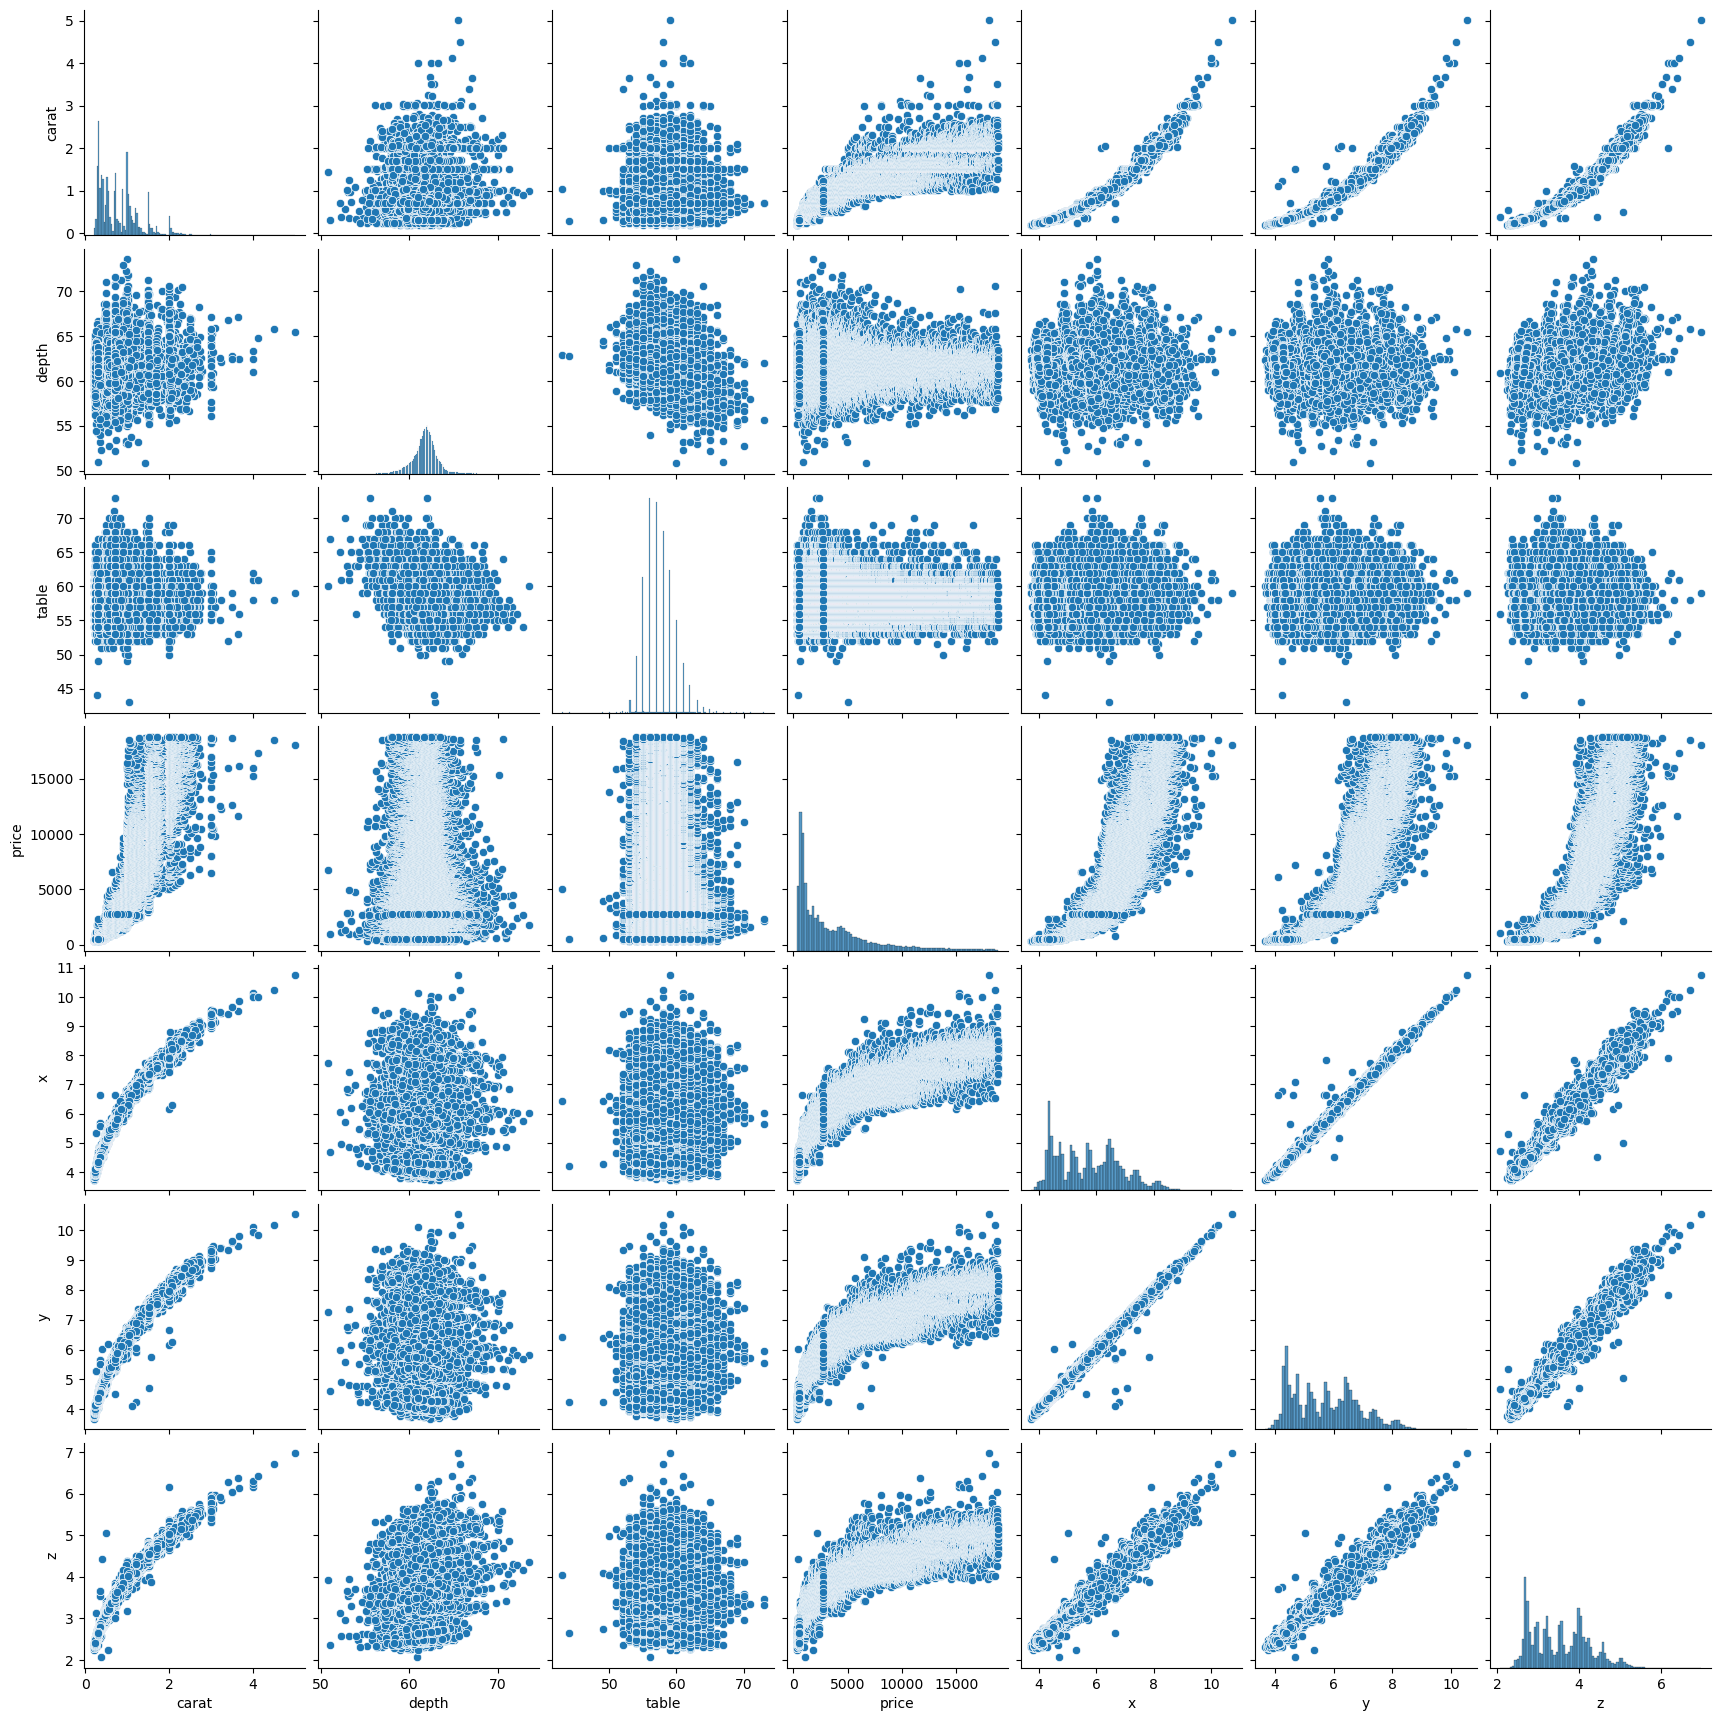

In [61]:
sns.pairplot(df)
plt.show()

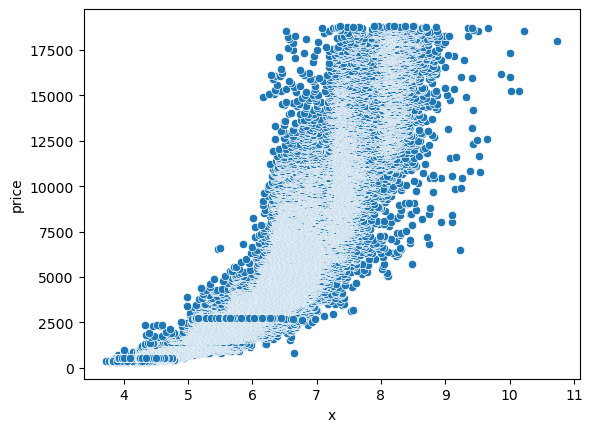

In [27]:
sns.scatterplot(x=df["x"],y=df ["price"])
plt.show()

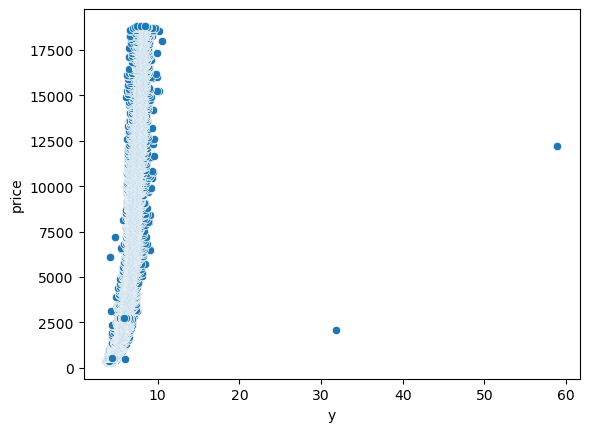

In [28]:
sns.scatterplot(x=df["y"],y=df ["price"])
plt.show()

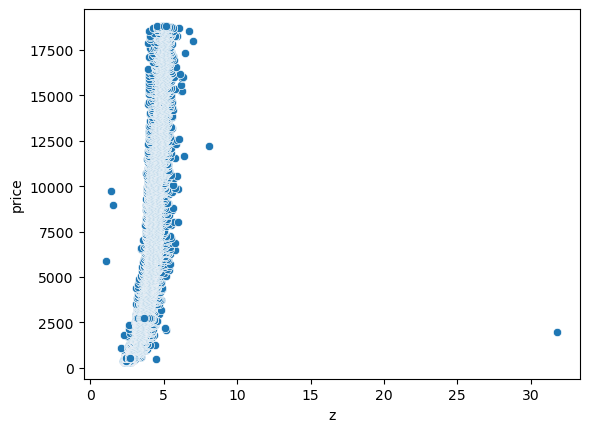

In [29]:
sns.scatterplot(x=df["z"],y=df ["price"])
plt.show()

In [30]:
# y ve z de aşırı büyük  aykırı deger var bunları çıkartmak daha iyi olur

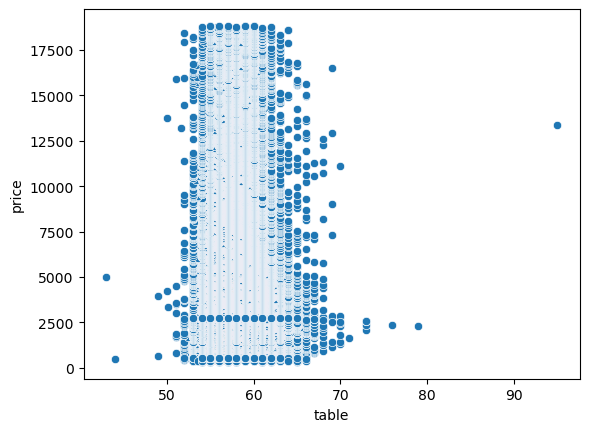

In [31]:
sns.scatterplot(x=df["table"],y=df ["price"])
plt.show()

In [32]:
df["depth"] < 75 

0        True
1        True
2        True
3        True
4        True
         ... 
53935    True
53936    True
53937    True
53938    True
53939    True
Name: depth, Length: 53920, dtype: bool

In [33]:
df[(df["depth"] < 75) & (df["depth"] > 45) ]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [34]:
len(df[(df["depth"] < 75) & (df["depth"] > 45) ])

53914

In [35]:
len(df)

53920

In [36]:
len(df[(df["table"] < 80) & (df["table"] > 40) ])

53919

In [37]:
len(df[(df["z"] < 30) & (df["z"] > 2) ])

53916

In [38]:
len(df[(df["y"] < 20)])

53918

In [39]:
df = df[(df["depth"] < 75) & (df["depth"] > 45) ]
df = df[(df["table"] < 75) & (df["table"] > 40) ]
df = df[(df["z"] < 30) & (df["z"] > 2)]
df = df[(df["y"] < 20)]

In [40]:
df.describe()

,carat,depth,table,price,x,y,z
count,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000
mean,0.797628,61.749545,57.455205,3930.643799,5.731476,5.733313,3.539443
std,0.473774,1.419739,2.222825,3987.264881,1.119402,1.111267,0.691446
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,5.010000,73.600000,73.000000,18823.000000,10.740000,10.540000,6.980000


In [41]:
# 53907 ye kadar düşürdük 

In [42]:
# şimdi grafikleri bir daha çizdirelim öyle yorum yapalım

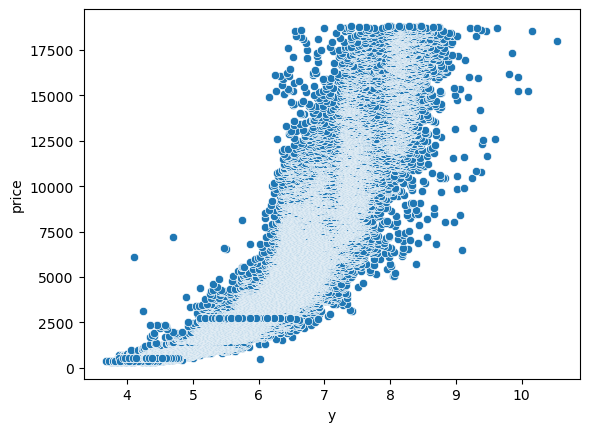

In [43]:
sns.scatterplot(x=df["y"],y=df ["price"])
plt.show()

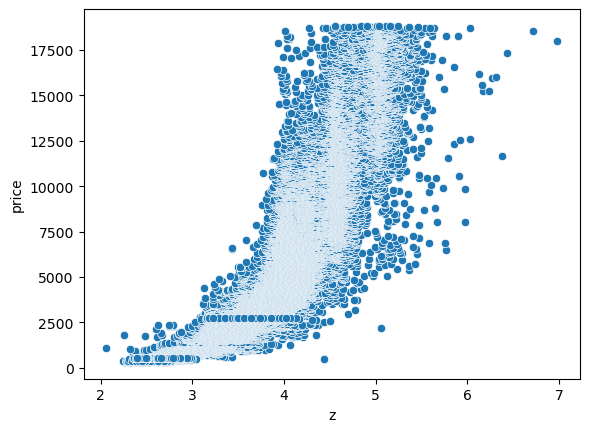

In [44]:
sns.scatterplot(x=df["z"],y=df ["price"])
plt.show()

In [45]:
# y ve z daha açık bir şekilde ilişki göryoruz artık 

In [46]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [47]:
df["cut"].value_counts()

cut
Ideal        21543
Premium      13779
Very Good    12080
Good          4902
Fair          1601
Name: count, dtype: int64

In [48]:
# hepsi düzgün bazen very good ve very   good şeklinde olabiliryor onları birleştirmemiz gerekir veride

In [49]:
df["color"].value_counts()

color
G    11281
E     9792
F     9535
H     8296
D     6774
I     5420
J     2807
Name: count, dtype: int64

In [50]:
df["clarity"].value_counts()

clarity
SI1     13058
VS2     12250
SI2      9183
VS1      8167
VVS2     5066
VVS1     3654
IF       1790
I1        737
Name: count, dtype: int64

In [51]:
X = df.drop("price",axis=1)
y =  df["price"]

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [54]:
X_train

,carat,cut,color,clarity,depth,table,x,y,z
15200,1.15,Ideal,H,SI1,62.4,54.0,6.71,6.76,4.20
14632,1.11,Premium,E,SI1,61.3,58.0,6.66,6.61,4.07
19151,1.21,Good,F,VS2,63.7,58.0,6.67,6.71,4.26
29299,0.30,Ideal,I,VS2,61.5,58.0,4.28,4.31,2.64
9983,1.00,Very Good,F,SI1,63.1,57.0,6.37,6.33,4.01
...,...,...,...,...,...,...,...,...,...
49042,0.51,Very Good,E,VVS2,62.1,55.0,5.14,5.16,3.20
2695,0.90,Very Good,G,SI2,63.4,59.0,6.08,6.04,3.84
8082,1.01,Premium,D,SI2,61.8,57.0,6.47,6.42,3.98
53016,0.71,Good,G,VS2,64.0,55.0,5.65,5.67,3.62


In [55]:
from sklearn.preprocessing import LabelEncoder

In [56]:
label_encoder = LabelEncoder()

In [57]:
for col in ["cut","color","clarity"]:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

In [58]:
X_train["cut"].value_counts()

cut
2    16164
3    10371
4     9018
1     3684
0     1191
Name: count, dtype: int64

In [59]:
X_train.head()

,carat,cut,color,clarity,depth,table,x,y,z
15200,1.15,2,4,2,62.4,54.0,6.71,6.76,4.20
14632,1.11,3,1,2,61.3,58.0,6.66,6.61,4.07
19151,1.21,1,2,5,63.7,58.0,6.67,6.71,4.26
29299,0.30,2,5,5,61.5,58.0,4.28,4.31,2.64
9983,1.00,4,2,2,63.1,57.0,6.37,6.33,4.01


In [60]:
X_test["cut"].value_counts()

cut
2    5379
3    3408
4    3062
1    1218
0     410
Name: count, dtype: int64

In [62]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40428 entries, 15200 to 7630
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    40428 non-null  float64
 1   cut      40428 non-null  int64  
 2   color    40428 non-null  int64  
 3   clarity  40428 non-null  int64  
 4   depth    40428 non-null  float64
 5   table    40428 non-null  float64
 6   x        40428 non-null  float64
 7   y        40428 non-null  float64
 8   z        40428 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 3.1 MB


In [63]:
X_train.describe()

,carat,cut,color,clarity,depth,table,x,y,z
count,40428.000000,40428.000000,40428.000000,40428.000000,40428.000000,40428.000000,40428.000000,40428.000000,40428.000000
mean,0.796222,2.552612,2.596567,3.837761,61.753070,57.457099,5.727558,5.729274,3.537217
std,0.474151,1.025862,1.702791,1.722900,1.412191,2.222914,1.119944,1.111769,0.692054
min,0.200000,0.000000,0.000000,0.000000,51.000000,43.000000,3.730000,3.680000,2.240000
25%,0.400000,2.000000,1.000000,2.000000,61.100000,56.000000,4.710000,4.720000,2.910000
50%,0.700000,2.000000,3.000000,4.000000,61.800000,57.000000,5.690000,5.700000,3.520000
75%,1.040000,3.000000,4.000000,5.000000,62.500000,59.000000,6.540000,6.530000,4.030000
max,5.010000,4.000000,6.000000,7.000000,73.600000,73.000000,10.740000,10.540000,6.980000


In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()

In [71]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [72]:
# artık  modeli egitmemiz gerekiyor ona başlayalım

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mean absolute error: 867.7716773299011
mean squared error 1849507.2709594548
R2 score 0.8848902306205187


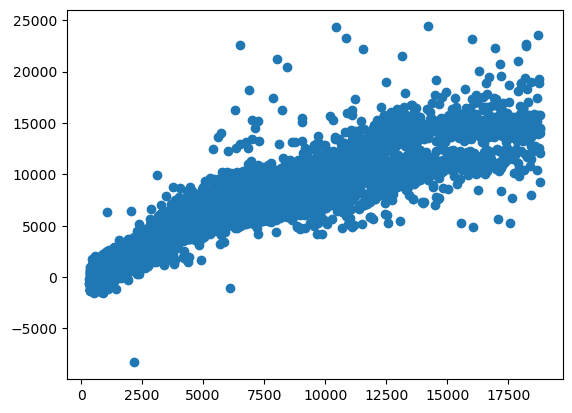

In [81]:
linear = LinearRegression()
linear.fit(X_train_scaler,y_train)
y_pred =linear.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error:",mae)
print("mean squared error",mse)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.show()

In [76]:
from sklearn.svm import SVR

mean absolute error: 1397.853335232954
mean squared error 8151981.8967523305
R2 score 0.4926363519327642


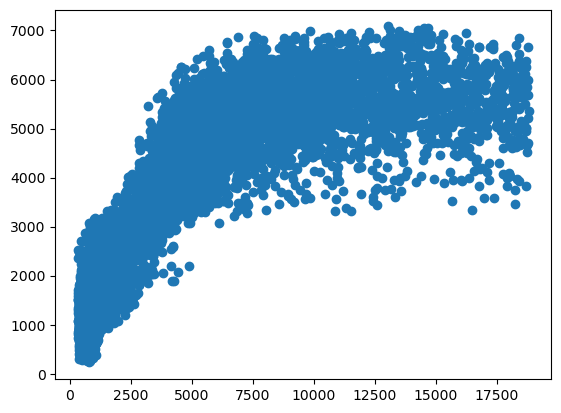

In [82]:
svr = SVR()
svr.fit(X_train_scaler,y_train)
y_pred =svr.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error:",mae)
print("mean squared error",mse)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.show()

In [83]:
# çok düşük çıktı SVR bundan dolayı hyperparametre yapmamız lazım daha iyi bir sonuç için

In [84]:
from sklearn.model_selection import GridSearchCV

In [87]:
param_grid = {
    "C": [0.1,1,10,100,1000],
    "gamma": [1,0.1,0.001],
    "kernel":["rbf","linear"]
}

In [88]:
grid = GridSearchCV(estimator=SVR(),param_grid= param_grid,n_jobs=-1,verbose=3)

In [89]:
# bu yukarıdaki işlem çok uzun sürecek onu bekle

In [90]:
 # grid.best_params_  yapıcaz

In [91]:
# y_pred =grid.predict(X_test_scaler)
# mae = mean_absolute_error(y_test,y_pred)
# mse = mean_squared_error(y_test,y_pred)
# score = r2_score(y_test,y_pred)
# print("mean absolute error:",mae)
# print("mean squared error",mse)
# print("R2 score",score)
# plt.scatter(y_test,y_pred)
# plt.show()

In [92]:
# yukarıda koddan bir grafik çıkca ve r2 socur 094 çıkıcak en iyi versiyoana çıkıcak ama çok bekliyorsun